In [1]:

# Imports
import geopandas as gpd
import matplotlib.pyplot as plt
import h3
import json
import pandas as pd
from shapely.geometry import shape
import contextily as ctx
H3_HEXAGON_RESOLUTION = 7
BOUNDARIES_DATA_PATH = '../data/chicago_boundaries.geojson'
POI_DATA_PATH = '../data/poi_chicago.geojson'

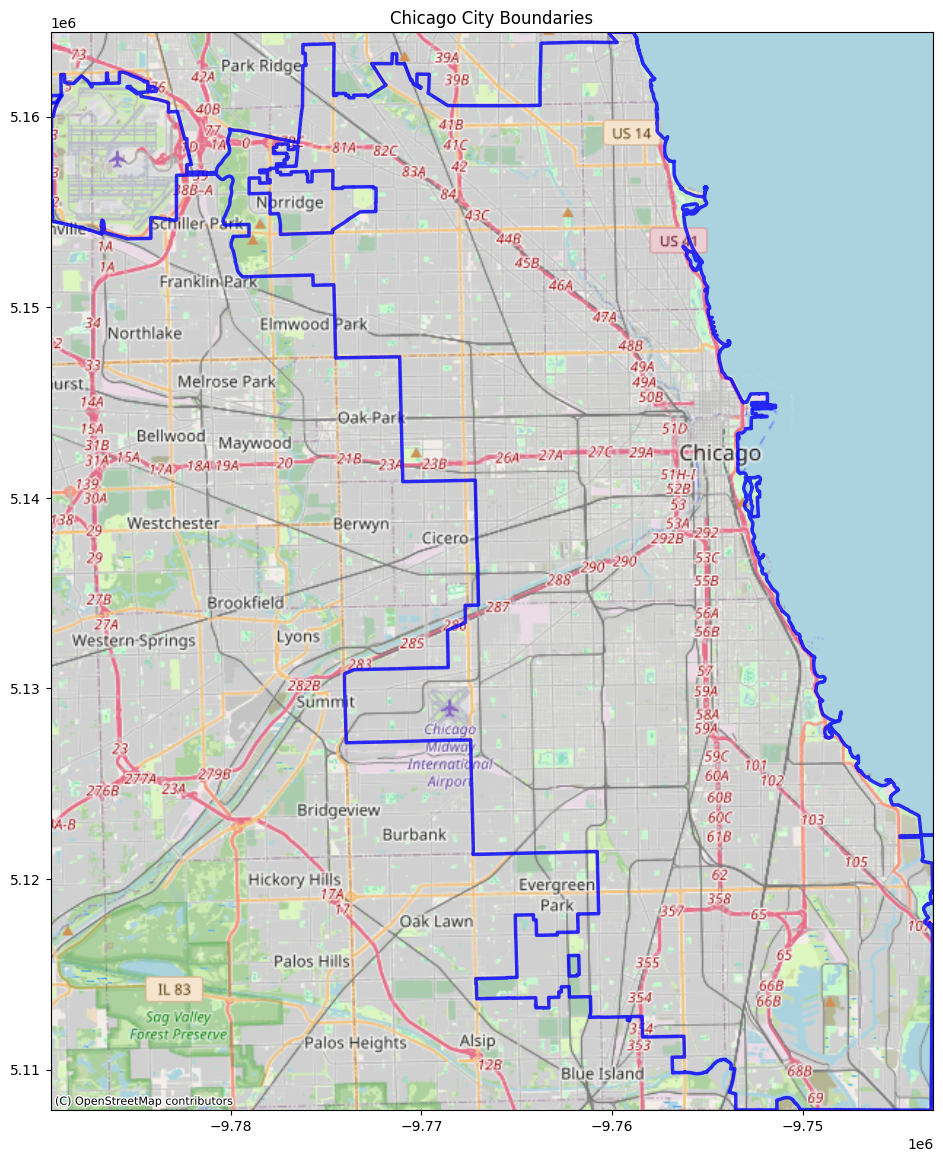

In [2]:
city = gpd.read_file(BOUNDARIES_DATA_PATH)
city_geo = city.geometry

fig, ax = plt.subplots(figsize=(14, 14))

# Convert to Web Mercator
city_bounds = gpd.GeoDataFrame(geometry=city_geo, crs='EPSG:4326').to_crs(epsg=3857)

# Plot first (so the extent exists)
city_bounds.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2.5, alpha=0.8)

# Set extent for contextily
ax.set_xlim(city_bounds.total_bounds[0], city_bounds.total_bounds[2])
ax.set_ylim(city_bounds.total_bounds[1], city_bounds.total_bounds[3])

# Add basemap
ctx.add_basemap(ax, crs=city_bounds.crs, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Chicago City Boundaries')
plt.show()


In [3]:
city_bounding_box_json_string = city_geo.to_json()
city_bounding_box_json = json.loads(city_bounding_box_json_string)
city_bounding_box_poly = city_bounding_box_json["features"][0]

# Computing hexagons for a given polygon
polygon_obj = city_bounding_box_poly["geometry"] # your geo json object
hexagons = h3.geo_to_cells(polygon_obj, res = H3_HEXAGON_RESOLUTION)

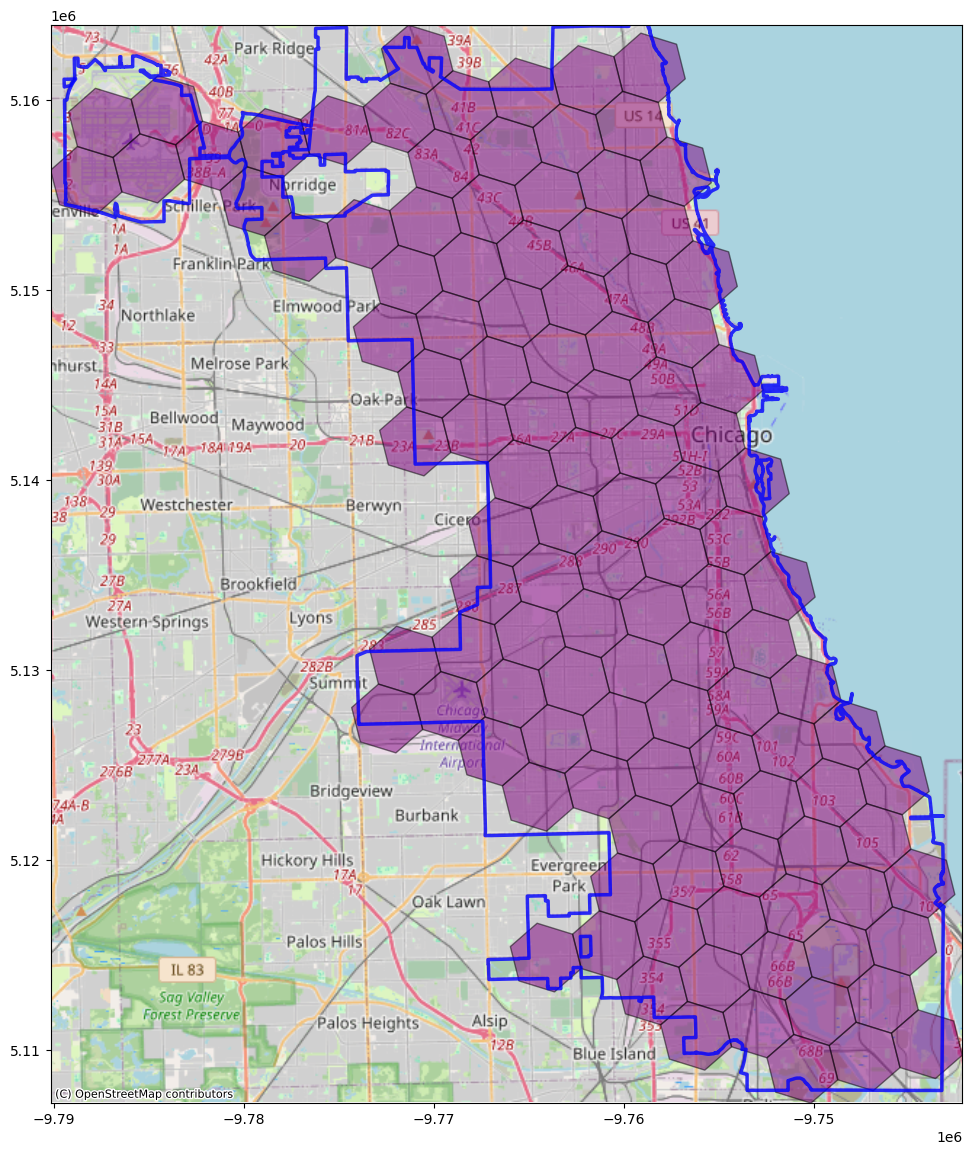

In [4]:
# Convert H3 hexes to geometry
# Create geometry series first
hex_geometries = [shape(h3.cells_to_geo([h])) for h in hexagons]

# Create GeoDataFrame with geometry from the start
df_boundaries = gpd.GeoDataFrame(
    {"h3_hex_id": list(hexagons)},
    geometry=hex_geometries,
    crs="EPSG:4326"
)

# Convert both to Web Mercator
df_web = df_boundaries.to_crs(3857)
city_bounds = city.to_crs(3857)

fig, ax = plt.subplots(figsize=(14, 14))

# Plot both in the same crs
df_web.plot(ax=ax, facecolor='purple', edgecolor='black', alpha=0.5)
city_bounds.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2.5, alpha=0.8)

# Set extent from hexes
ax.set_xlim(df_web.total_bounds[0], df_web.total_bounds[2])
ax.set_ylim(df_web.total_bounds[1], df_web.total_bounds[3])

# Add basemap
ctx.add_basemap(ax, crs=df_web.crs, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()

In [5]:
gdf_poi = gpd.read_file(POI_DATA_PATH)

Count stats: min=64, max=8934, mean=637.0603448275862


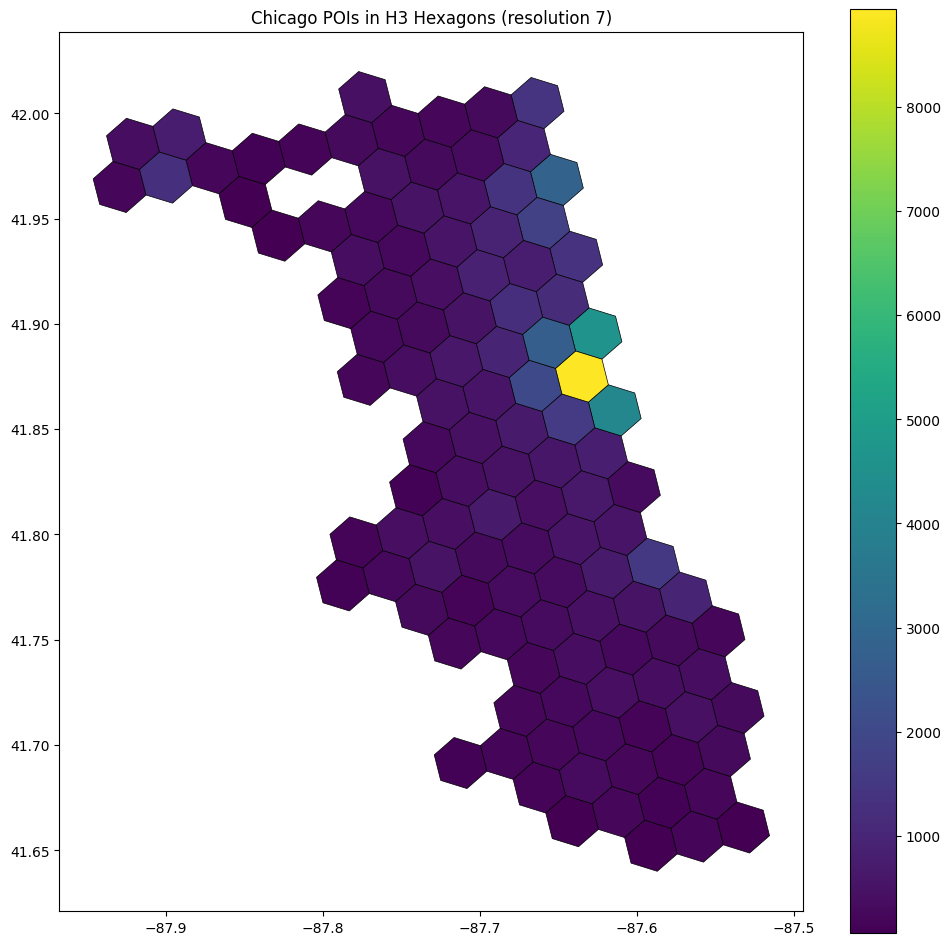

In [6]:
# Filter to points within city bounds
gdf_filtered = gdf_poi.cx[city_geo.total_bounds[0]:city_geo.total_bounds[2], 
                       city_geo.total_bounds[1]:city_geo.total_bounds[3]]

# Count POIs per hexagon using the pre-existing hexagon grid
gdf_filtered['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                              for lat, lon in zip(gdf_filtered.geometry.y, gdf_filtered.geometry.x)]

# Count POIs per hexagon
poi_counts = gdf_filtered.groupby('h3_hex_id').size().reset_index(name='count')

# Make sure df_boundaries is in the right CRS (EPSG:4326) before merging
df_boundaries_reset = df_boundaries.to_crs('EPSG:4326') if df_boundaries.crs != 'EPSG:4326' else df_boundaries

# Merge counts with the pre-existing hexagon geometries
coords_poi_geo = df_boundaries_reset.merge(poi_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
coords_poi_geo['count'] = coords_poi_geo['count'].fillna(0)

print(f"Count stats: min={coords_poi_geo['count'].min()}, max={coords_poi_geo['count'].max()}, mean={coords_poi_geo['count'].mean()}")

# Now plot
fig, ax = plt.subplots(figsize=(12, 12))

coords_poi_geo.plot(
    ax=ax,
    column="count",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Chicago POIs in H3 Hexagons (resolution {})".format(H3_HEXAGON_RESOLUTION))
plt.show()

In [7]:
filter_list = ['amenity', 'tourism', 'shop', 'leisure',
               'office', 'healthcare', 'historic', 'man_made',
               'natural', 'craft', 'sport', 'place', 'railway',
               'public_transport', 'aeroway', 'emergency']


filtered = {}

for col in filter_list:
    filtered[col] = gdf_filtered[gdf_filtered[col].notna()]
    
for key, value in filtered.items():
    print(f"{key}: {len(value)}")

amenity: 16445
tourism: 1038
shop: 4042
leisure: 709
office: 713
healthcare: 557
historic: 366
man_made: 5479
natural: 26531
craft: 112
sport: 147
place: 282
railway: 9352
public_transport: 16333
aeroway: 1045
emergency: 470


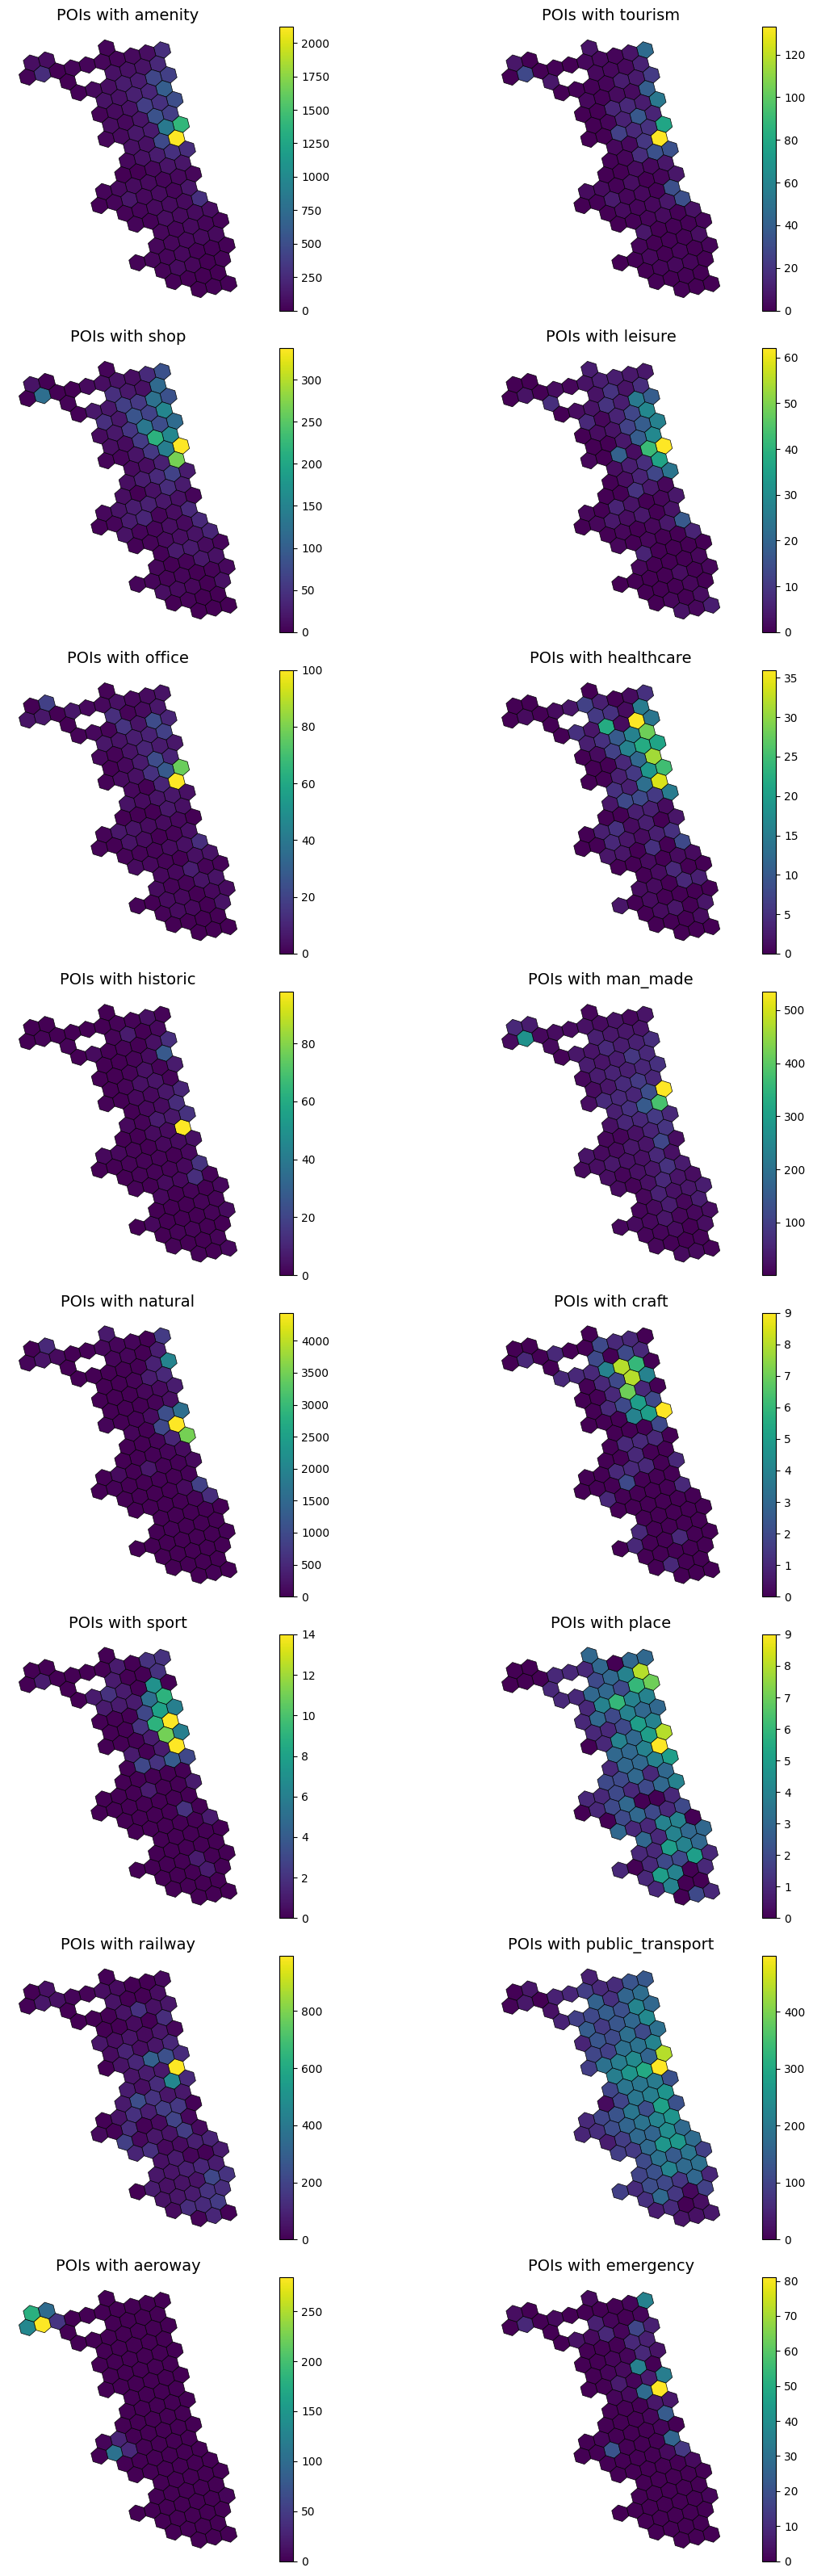

In [8]:

n_plots = len(filtered)
n_cols = 2
n_rows = 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 32))
axes = axes.flatten()

hex_data_list = []

# First pass: prepare data
for key, value in filtered.items():
    value_copy = value.copy()
    value_copy['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                               for lat, lon in zip(value_copy.geometry.y, value_copy.geometry.x)]
    
    type_counts = value_copy.groupby('h3_hex_id').size().reset_index(name='count')
    hex_data = df_boundaries.merge(type_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
    hex_data['count'] = hex_data['count'].fillna(0)
    hex_data_list.append(hex_data)

# Second pass: plot with individual color scales
for i, (key, hex_data) in enumerate(zip(filtered.keys(), hex_data_list)):
    ax = axes[i]
    hex_data.plot(ax=ax, column='count', cmap='viridis', legend=True, 
                  edgecolor='black', linewidth=0.5)
    ax.set_title(f"POIs with {key}", fontsize=14)
    ax.axis('off')

# Hide unused subplots
for j in range(len(filtered), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()